# Quantum Teleportation Protocol

Quantum teleportation is a fundamental protocol in quantum computing that transmits a quantum state $|\psi\rangle$ from one location (Alice) to another (Bob) without physically moving the particle itself. It relies on the phenomena of **quantum entanglement** and classical communication.

### How it works:
1. **Shared Entanglement:** Alice and Bob share a pair of entangled qubits (a Bell state). Alice keeps one, and Bob takes the other.
2. **Alice's Operations:** Alice performs a joint quantum operation (CNOT and Hadamard gates) on the secret message qubit and her entangled qubit.
3. **Alice's Measurement:** Alice measures both of her qubits. According to the No-Cloning Theorem, this destroys the original quantum state, but yields two classical bits of information.
4. **Bob's Correction:** Alice sends these two classical bits to Bob via a standard communication channel (e.g., internet or phone). Based on these bits, Bob applies specific Pauli gates ($X$ and/or $Z$) to his entangled qubit. This forces his qubit to assume the exact state of Alice's original message.

In [10]:
# --- Setup and Initialization ---
from qiskit import QuantumCircuit

# Create a circuit with 3 quantum bits and 3 classical bits
# q_0: Alice's secret message
# q_1: Alice's entangled half
# q_2: Bob's entangled half
qc = QuantumCircuit(3, 3)

# --- Step 1: Create the entangled Bell state ---
qc.h(1)
qc.cx(1, 2)

qc.barrier()

# --- Step 2: Alice's encoding operations ---
qc.cx(0, 1)
qc.h(0)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

### Step 1 to 3: Entanglement, Encoding, and Measurement

First, we need to create the quantum communication channel. We entangle Alice's second qubit ($q_1$) with Bob's qubit ($q_2$) to create a Bell state $|\Phi^+\rangle$. 

Then, Alice encodes her secret message ($q_0$) into the entangled system and performs measurements on her side.

=== Quantum Teleportation Circuit (Deferred Measurement) ===


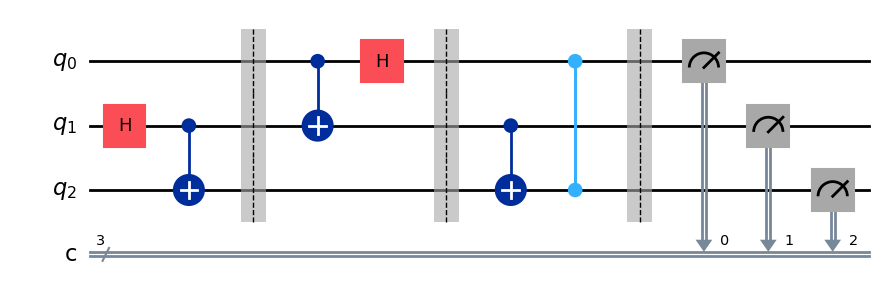

In [11]:
# --- Step 3: Bob's Quantum Correction (Deferred Measurement) ---
# Apply Controlled-X based on Alice's q1
qc.cx(1, 2)

# Apply Controlled-Z based on Alice's q0
qc.cz(0, 2)

qc.barrier()

# --- Step 4: Classic Measurement ---
# Measure all 3 qubits into the 3 classical bits at the very end
qc.measure([0, 1, 2], [0, 1, 2])

print("=== Quantum Teleportation Circuit (Deferred Measurement) ===")
qc.draw('mpl')

### Step 4: Bob's Correction (Dynamic Circuit)

Bob receives the two classical bits (`crz` and `crx`) from Alice. Depending on their values, he must apply the appropriate quantum gates to his qubit ($q_2$) to reconstruct the original state:
* If `crx = 1`, apply the **Pauli-X** gate.
* If `crz = 1`, apply the **Pauli-Z** gate.

In Qiskit, we achieve this using the `.c_if()` method, which conditionally applies a quantum gate based on the value of a classical register.

In [12]:
# --- Step 5: Simulation and Verification ---
from qiskit_aer import Aer
from qiskit import transpile

print("=== Running Quantum Teleportation Simulation ===")

# 1. Initialize the local simulator
simulator = Aer.get_backend('aer_simulator')

# 2. Transpile and run the circuit
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# 3. Get and print the measurement counts
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")

# 4. Analyze the results to prove teleportation
print("\n--- Analysis ---")
print("Qiskit reads classical bits from right to left (c2 c1 c0).")
print(" -> c2 (Leftmost bit): Bob's qubit (The teleported message)")
print(" -> c1 (Middle bit): Alice's entangled qubit measurement")
print(" -> c0 (Rightmost bit): Alice's original message measurement\n")

# Check if Bob always received '0' (since our initial message was in state |0>)
success = True
for bitstring in counts.keys():
    bobs_bit = bitstring[0] # Leftmost character
    if bobs_bit != '0':
        success = False
        break

if success:
    print("✅ SUCCESS: Bob's qubit is ALWAYS '0', regardless of Alice's random measurements!")
else:
    print("❌ ERROR: Teleportation failed.")

=== Running Quantum Teleportation Simulation ===
Raw measurement counts: {'001': 253, '010': 260, '011': 267, '000': 244}

--- Analysis ---
Qiskit reads classical bits from right to left (c2 c1 c0).
 -> c2 (Leftmost bit): Bob's qubit (The teleported message)
 -> c1 (Middle bit): Alice's entangled qubit measurement
 -> c0 (Rightmost bit): Alice's original message measurement

✅ SUCCESS: Bob's qubit is ALWAYS '0', regardless of Alice's random measurements!
